In [1]:
import sys
# Add your lenscarf site-packages to the path
sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')

import numpy as np

sys.path.append('/users/odarwish/nbodykit/')
import nbodykit
from nbodykit.lab import ArrayCatalog

import matplotlib.pyplot as plt

In [2]:
path = '/users/odarwish/scratch/AbacusSummit_base_c000_ph000/'

In [3]:
import abacusnbody.metadata
meta = abacusnbody.metadata.get_meta('AbacusSummit_base_c000_ph000', redshift=0.1)
print(meta['OmegaNow_m'])  # Omega_M(z=0.1)
print(meta['OmegaNow_DE'])  # Omega_DE(z=0.1)

Dz = meta['GrowthTable']
ztarget = 0.1
zpk = meta['ZD_Pk_file_redshift']  # 1.0
pk = meta['CLASS_power_spectrum']
k  = pk['k (h/Mpc)']
input_pk = pk['P (Mpc/h)^3']
linear_pk = input_pk * (Dz[ztarget] / Dz[zpk])**2

0.379887444945823
0.620112555054177


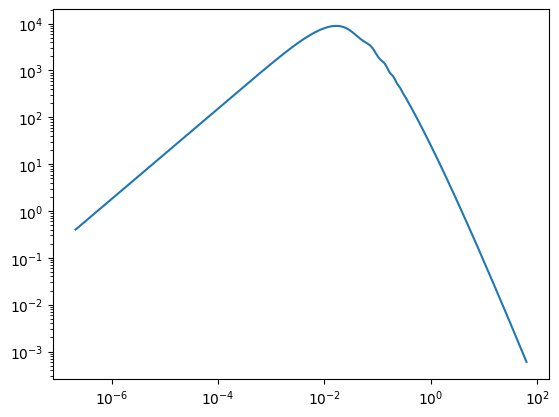

In [4]:
plt.loglog(k, input_pk)

In [5]:
from abacusnbody.analysis.power_spectrum import calc_power
from abacusnbody.data import read_abacus
from pathlib import Path

In [6]:
z = 0.1
path_to_sim = '/users/odarwish/scratch/AbacusSummit_base_c000_ph000/'+'/halos/z{:.3f}/'.format(z)
path_to_sim

'/users/odarwish/scratch/AbacusSummit_base_c000_ph000//halos/z0.100/'

In [7]:
allp = []
for fn in Path(path_to_sim).glob('*_rv_*/*.asdf'):
    batch = read_abacus.read_asdf(fn, load=['pos', 'vel'])
    batch_size = len(batch)
    #print('batch size: ', batch_size)
    #sample = np.random.uniform(0., 1., batch_size) < downsampling
    
    allp += [batch]

In [8]:
import astropy

allp = astropy.table.vstack(allp)

print(len(allp))

boxsize = 2000
positions = allp['pos']
velocities = allp['vel']
nbar = len(positions) / (boxsize**3)
print('nbar: ', nbar)

4209883445
nbar:  0.526235430625


In [9]:
positions_reshaped = np.array(positions.T, dtype='f8')
velocities_reshaped = np.array(velocities.T, dtype='f8')

In [10]:
positions_reshaped.shape

(3, 4209883445)

In [11]:
from nbodykit.lab import *
catalog = ArrayCatalog({
        'Position': positions_reshaped.T}, BoxSize=boxsize)

In [12]:
mesh = catalog.to_mesh(Nmesh=512, resampler='tsc', compensated=True)

In [15]:
density = mesh.compute(mode="real")

KeyboardInterrupt: 

In [ ]:
density -= 1

In [14]:
kmin = np.pi/boxsize
r = FFTPower(density, mode='1d', dk=0.01, kmin=kmin)

KeyboardInterrupt: 

In [18]:
from abacusnbody.data.compaso_halo_catalog import CompaSOHaloCatalog

path_to_sim = "/capstor/scratch/cscs/odarwish/ABACUS/AbacusSummit_base_c000_ph000/halos/z0.100"
cat = CompaSOHaloCatalog(path_to_sim, subsamples=dict(A=True,pos=True))

KeyboardInterrupt: 

In [ ]:
print(cat.halos[:5])  # cat.halos is an Astropy Table, print the first 5 rows